In [1]:
import pandas as pd

In [2]:
df = pd.read_parquet('data/market_data_enriched.parquet')

df.head()

,Close,High,Low,Open,Volume,RSI,Volatility,SMA_50,Dist_SMA_50,target,SMA_200,Dist_SMA_200,Vol_Change,Fed_Rate,Unemployment,Inflation
Date,,,,,,,,,,,,,,,,
2010-11-01,1184.380005,1195.810059,1177.650024,1185.709961,4129180000,64.026282,0.007102,1134.719597,0.043764,1,1122.793897,0.054851,0.167134,0.19,9.8,219.59
2010-11-02,1193.569946,1195.880005,1187.859985,1187.859985,3866200000,68.366477,0.006865,1137.243796,0.049529,1,1123.010597,0.062831,-0.063688,0.19,9.8,219.59
2010-11-03,1197.959961,1198.300049,1183.560059,1193.790039,4665480000,70.215138,0.005418,1140.165596,0.050689,1,1123.310197,0.066455,0.206735,0.19,9.8,219.59
2010-11-04,1221.060059,1221.250000,1198.339966,1198.339966,5695470000,77.624939,0.006629,1143.480198,0.067845,1,1123.833097,0.086514,0.220768,0.19,9.8,219.59
2010-11-05,1225.849976,1227.079956,1220.290039,1221.199951,5637460000,78.802528,0.006567,1147.052798,0.068695,0,1124.503547,0.090125,-0.010185,0.19,9.8,219.59


In [3]:
print(f"columns : {df.columns}")

print(f"count : {df.count()}")

columns : Index(['Close', 'High', 'Low', 'Open', 'Volume', 'RSI', 'Volatility', 'SMA_50',
       'Dist_SMA_50', 'target', 'SMA_200', 'Dist_SMA_200', 'Vol_Change',
       'Fed_Rate', 'Unemployment', 'Inflation'],
      dtype='str')
count : Close           3847
High            3847
Low             3847
Open            3847
Volume          3847
RSI             3847
Volatility      3847
SMA_50          3847
Dist_SMA_50     3847
target          3847
SMA_200         3847
Dist_SMA_200    3847
Vol_Change      3847
Fed_Rate        3847
Unemployment    3847
Inflation       3847
dtype: int64


In [4]:
print(f"summary {df.describe()}" )

summary              Close         High          Low         Open        Volume  \
count  3847.000000  3847.000000  3847.000000  3847.000000  3.847000e+03   
mean   3077.014915  3092.647317  3058.970348  3076.422597  3.988852e+09   
std    1503.001707  1510.358167  1494.729657  1502.943252  9.851074e+08   
min    1099.229980  1125.119995  1074.770020  1097.420044  0.000000e+00   
25%    1937.350037  1948.225037  1923.684998  1935.664978  3.384110e+09   
50%    2706.530029  2726.110107  2689.820068  2705.600098  3.809760e+09   
75%    4155.020020  4174.255127  4125.210205  4153.364990  4.410535e+09   
max    6978.600098  7002.279785  6963.459961  7002.000000  9.976520e+09   

               RSI   Volatility       SMA_50  Dist_SMA_50       target  \
count  3847.000000  3847.000000  3847.000000  3847.000000  3847.000000   
mean     55.755982     0.009185  3040.391945     0.011697     0.545880   
std      11.166074     0.005879  1476.185854     0.034918     0.497955   
min      16.457584  

/home/vic/miniconda3/envs/proj_ia/lib/python3.12/site-packages/pandas/core/nanops.py:1020: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


<Axes: xlabel='Date'>

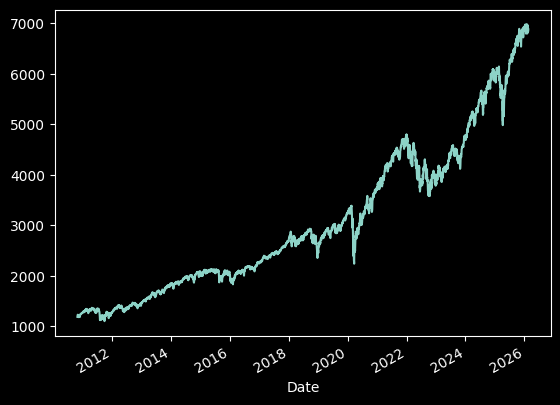

In [5]:
import matplotlib.pyplot as plt

df['Close'].plot()



<Axes: xlabel='Date'>

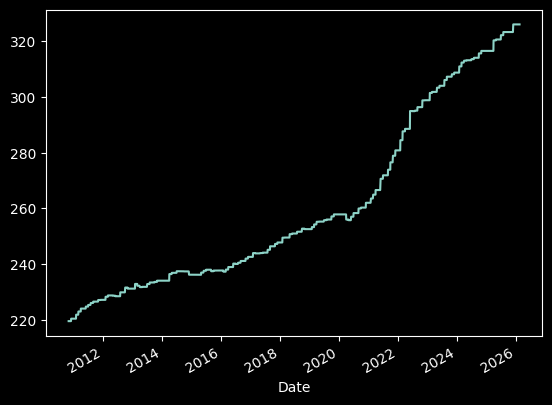

In [6]:
df["Inflation"].plot()


<Axes: xlabel='Date'>

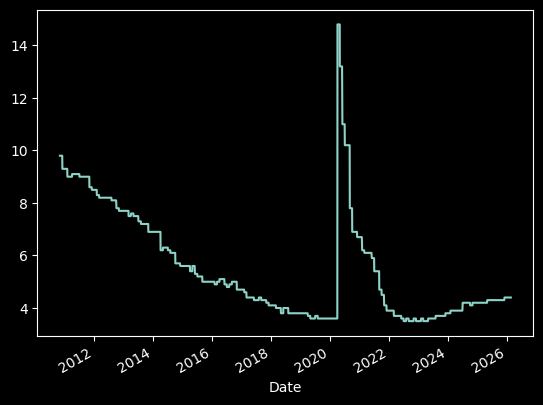

In [7]:
df["Unemployment"].plot()

<Axes: xlabel='Date'>

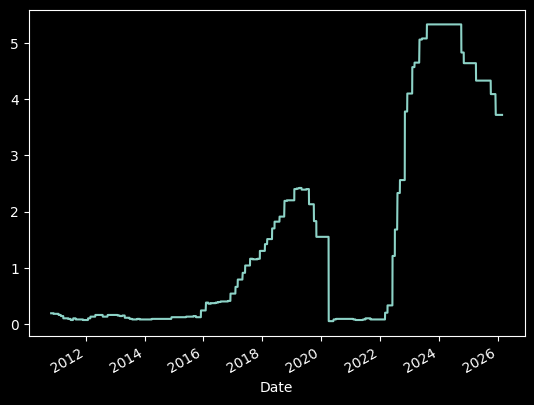

In [8]:
df["Fed_Rate"].plot()

In [9]:
df.isnull().sum()

Close           0
High            0
Low             0
Open            0
Volume          0
RSI             0
Volatility      0
SMA_50          0
Dist_SMA_50     0
target          0
SMA_200         0
Dist_SMA_200    0
Vol_Change      0
Fed_Rate        0
Unemployment    0
Inflation       0
dtype: int64

In [10]:
import numpy as np
df["Target"] = np.log(df["Close"]/df["Close"].shift(1))

In [11]:
print(f"test {df["Target"]}")

test Date
2010-11-01         NaN
2010-11-02    0.007729
2010-11-03    0.003671
2010-11-04    0.019099
2010-11-05    0.003915
                ...   
2026-02-11   -0.000049
2026-02-12   -0.015785
2026-02-13    0.000499
2026-02-17    0.001031
2026-02-18    0.005551
Name: Target, Length: 3847, dtype: float64


<Axes: xlabel='Date'>

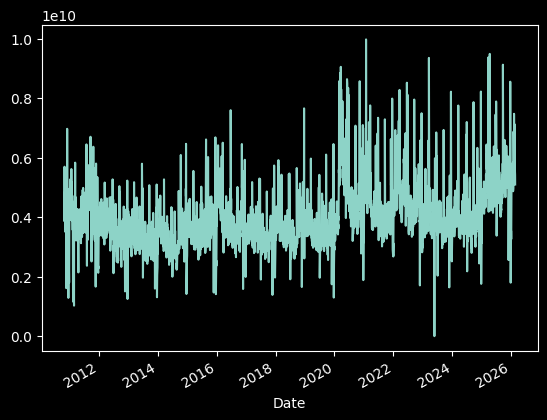

In [12]:
df["Volume"].plot()


<Axes: xlabel='Date'>

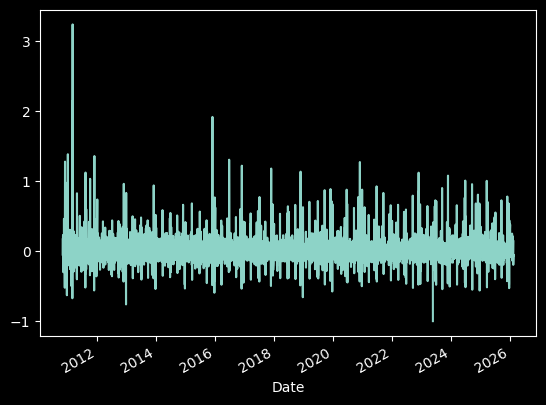

In [13]:
df["Vol_Change"].plot()

/home/vic/miniconda3/envs/proj_ia/lib/python3.12/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


<Axes: xlabel='Date'>

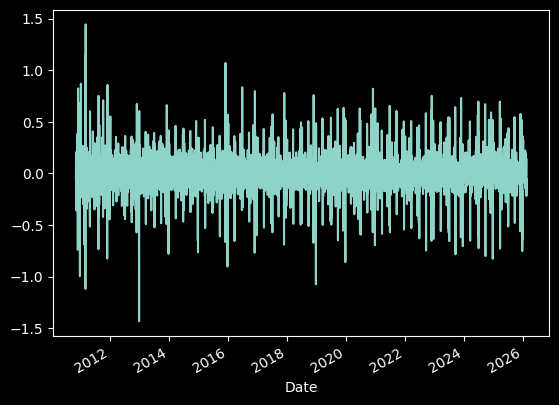

In [14]:
df['Log_Volume'] = np.log(df['Volume'])

df['Log_Vol_Change'] = df['Log_Volume'].diff()
df["Log_Vol_Change"].plot()

In [15]:
print(df["target"].describe())
print(df["target"].value_counts())

count    3847.000000
mean        0.545880
std         0.497955
min         0.000000
25%         0.000000
50%         1.000000
75%         1.000000
max         1.000000
Name: target, dtype: float64
target
1    2100
0    1747
Name: count, dtype: int64


<Axes: xlabel='Date'>

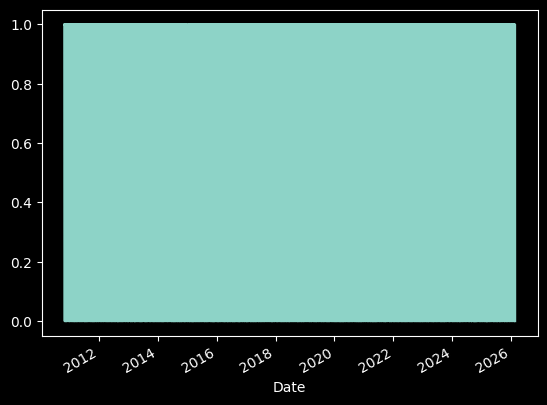

In [16]:
df["target"].plot()